In [3]:
from market_clearing import MarketClearing
from strategic_behavior import MPEC, MPEClinearized
import pandas as pd
import utils
from best_response import BR
import numpy as np

# Question 2

In [4]:
prod_df = pd.DataFrame({
    'producers': ['P1', 'P2', 'P3', 'P4'],
    'capacities': [40, 90, 50, 60], 
    'Pmax': [40, 90, 50, 60],       
    'Pmin': [0, 0, 0, 0],      
    'marginal_costs': [10, 30, 35, 55],
})

demand = 155

strategic_producer = 'P1'
mc = MarketClearing(bids=prod_df['marginal_costs'].to_list(), marginal_costs=prod_df['marginal_costs'].to_list(), demand=demand, prod_df=prod_df)
print(mc.get_price())

Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
QCPDual  1

Academic license 2635697 - for non-commercial use only - registered to s2___@dtu.dk
Optimize a model with 9 rows, 4 columns and 12 nonzeros
Model fingerprint: 0x5845b6b1
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 2e+02]
Presolve removed 8 rows and 1 columns
Presolve time: 0.01s
Presolved: 1 rows, 3 columns, 3 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.8500000e+03   3.125000e+00   0.000000e+00      0s
       1    3.9750000e+03   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and

## Trustful competitors

In [5]:
mpec = MPEClinearized(producer='P1', alphas=prod_df['marginal_costs'].to_list(), marginal_costs=prod_df['marginal_costs'].to_list(), prod_df=prod_df, demand=demand, bigM=200, upper_bid=200)
print(mpec.get_profit())
print(mpec.get_results())
profit = mpec.get_profit()

Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
QCPDual  1

Academic license 2635697 - for non-commercial use only - registered to s2___@dtu.dk
Optimize a model with 31 rows, 25 columns and 65 nonzeros
Model fingerprint: 0xc036227c
Variable types: 14 continuous, 11 integer (11 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+01, 2e+02]
  Bounds range     [1e+00, 2e+02]
  RHS range        [3e+01, 2e+02]
Found heuristic solution: objective -1000.000000
Presolve removed 20 rows and 19 columns
Presolve time: 0.01s
Presolved: 11 rows, 6 columns, 30 nonzeros
Variable types: 3 continuous, 3 integer (3 binary)

Root relaxation: cutoff, 2 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds 

Index([1, 0, 2, 3], dtype='int64')
0
Index([1, 0, 2, 3], dtype='int64')
1
0
Index([1, 0, 2, 3], dtype='int64')
2
2
Index([1, 0, 2, 3], dtype='int64')
3
3
   production  bids producer  capacities    color   xpos  cumulative_capa
1        90.0  30.0       P2          90  #8BBEB2   45.0               90
0        40.0  34.0       P1          40  #384E77  110.0              130
2        25.0  35.0       P3          50  #E6F9AF  155.0              180
3         0.0  55.0       P4          60     pink  210.0              240
Power plant that sets the electricity price is:  2


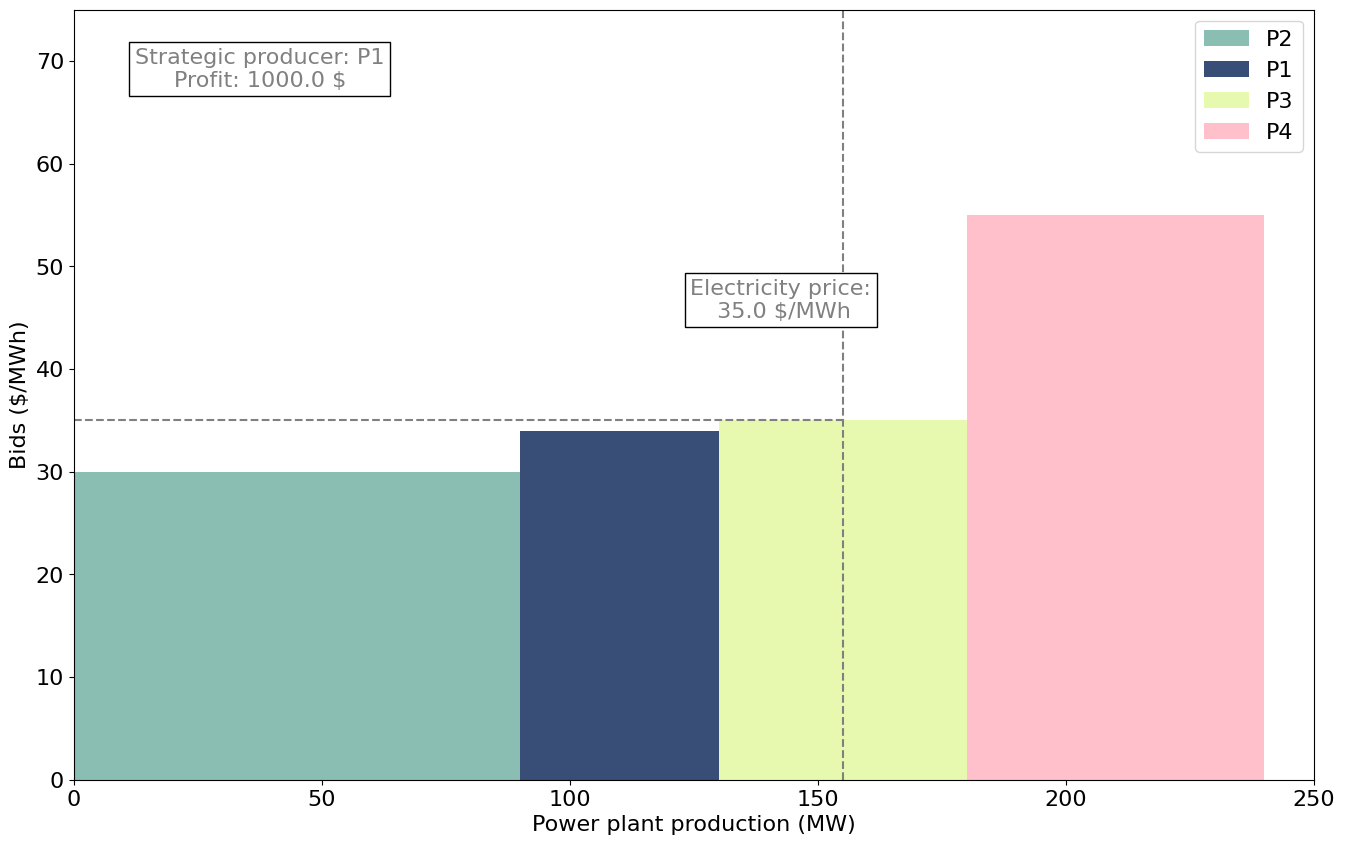

In [6]:
utils.plot_merit_order(mpec.get_results(), demand=demand, strategic_producer=strategic_producer, sp_profit=profit)

## Overbidding competitors

In [7]:
mpec = MPEClinearized(producer='P1', alphas=[10, 40, 45, 120], marginal_costs=prod_df['marginal_costs'].to_list(), prod_df=prod_df, demand=demand, bigM=200, upper_bid=200)
print(mpec.get_profit())
print(mpec.get_results())
profit = mpec.get_profit()

Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
QCPDual  1



Academic license 2635697 - for non-commercial use only - registered to s2___@dtu.dk
Optimize a model with 31 rows, 25 columns and 65 nonzeros
Model fingerprint: 0xa6ec9213
Variable types: 14 continuous, 11 integer (11 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+01, 2e+02]
  Bounds range     [1e+00, 2e+02]
  RHS range        [4e+01, 2e+02]
Found heuristic solution: objective -1400.000000
Presolve removed 24 rows and 21 columns
Presolve time: 0.00s
Presolved: 7 rows, 4 columns, 18 nonzeros
Variable types: 2 continuous, 2 integer (2 binary)

Root relaxation: objective -1.635000e+03, 2 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    -1635.000000 -1635.0000  0.00%     -    0s

Explored 1 nodes (2 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 16 (

Index([1, 2, 0, 3], dtype='int64')
0
Index([1, 2, 0, 3], dtype='int64')
1
2
Index([1, 2, 0, 3], dtype='int64')
2
0
Index([1, 2, 0, 3], dtype='int64')
3
3
   production   bids producer  capacities    color   xpos  cumulative_capa
1        90.0   40.0       P2          90  #8BBEB2   45.0               90
2        50.0   45.0       P3          50  #E6F9AF  115.0              140
0        15.0  119.0       P1          40  #384E77  160.0              180
3         0.0  120.0       P4          60     pink  210.0              240
Power plant that sets the electricity price is:  0


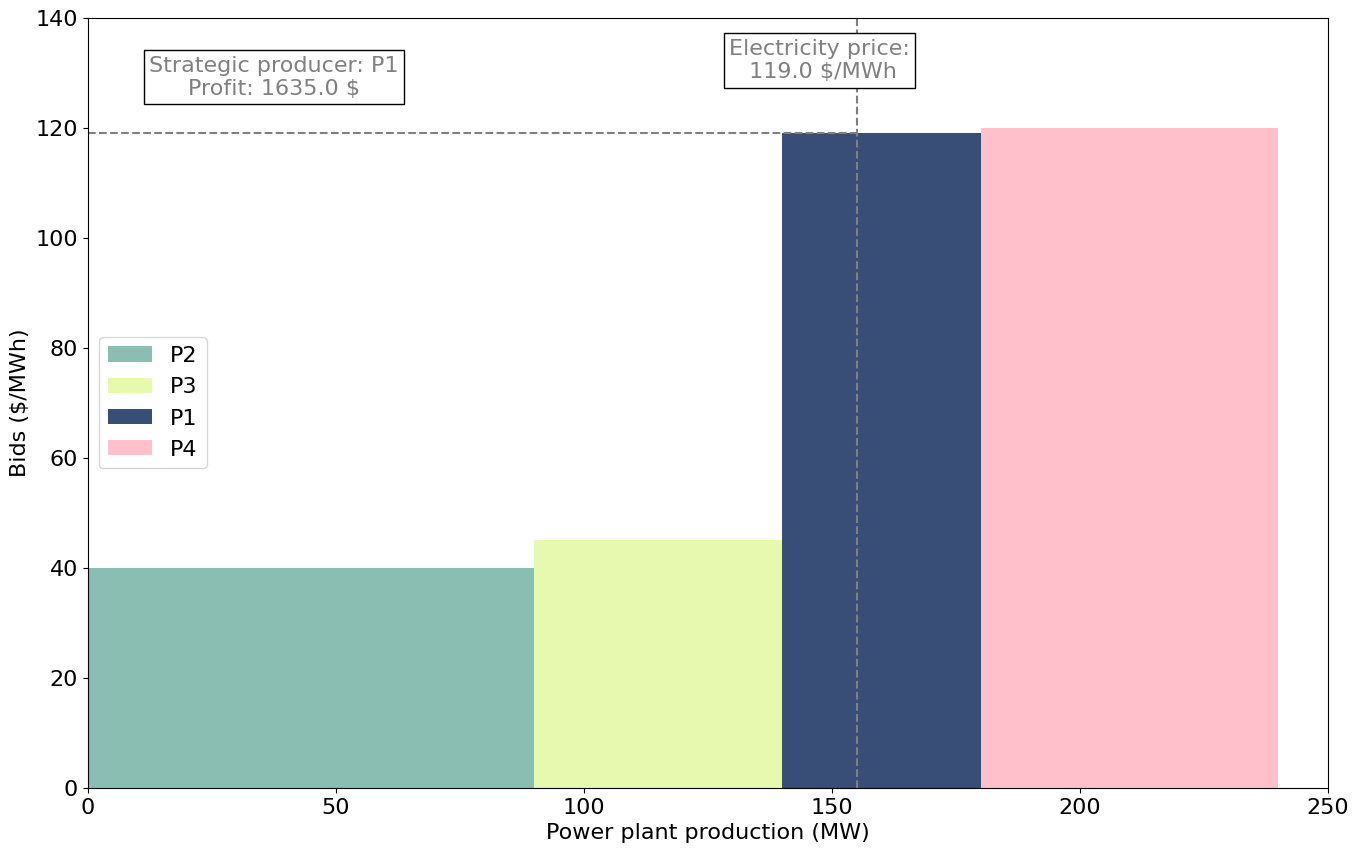

In [8]:
utils.plot_merit_order(mpec.get_results(), demand=demand, strategic_producer=strategic_producer, sp_profit=profit)

# Question 3

Using the same setup as the previous question, a Nash equilibrium is approached through best-response algorithm.

In [9]:
prod_df = pd.DataFrame({
    'producers': ['P1', 'P2', 'P3', 'P4'],
    'capacities': [40, 90, 50, 60], 
    'Pmax': [40, 90, 50, 60],       
    'Pmin': [0, 0, 0, 0],      
    'marginal_costs': [10, 30, 35, 55],
})

demand = 155
marginal_costs = [10, 30, 35, 55] 

In [10]:
br = BR(bids_init=marginal_costs, marginal_costs=marginal_costs, demand = demand, prod_df=prod_df, tolerance=0.01)
br.run_BR(200)

Strategic producer P1
Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
QCPDual  1

Academic license 2635697 - for non-commercial use only - registered to s2___@dtu.dk
Optimize a model with 9 rows, 4 columns and 12 nonzeros
Model fingerprint: 0x5845b6b1
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 2e+02]
Presolve removed 8 rows and 1 columns
Presolve time: 0.00s
Presolved: 1 rows, 3 columns, 3 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.8500000e+03   3.125000e+00   0.000000e+00      0s
       1    3.9750000e+03   0.000000e+00   0.000000e+00      0s

Solv

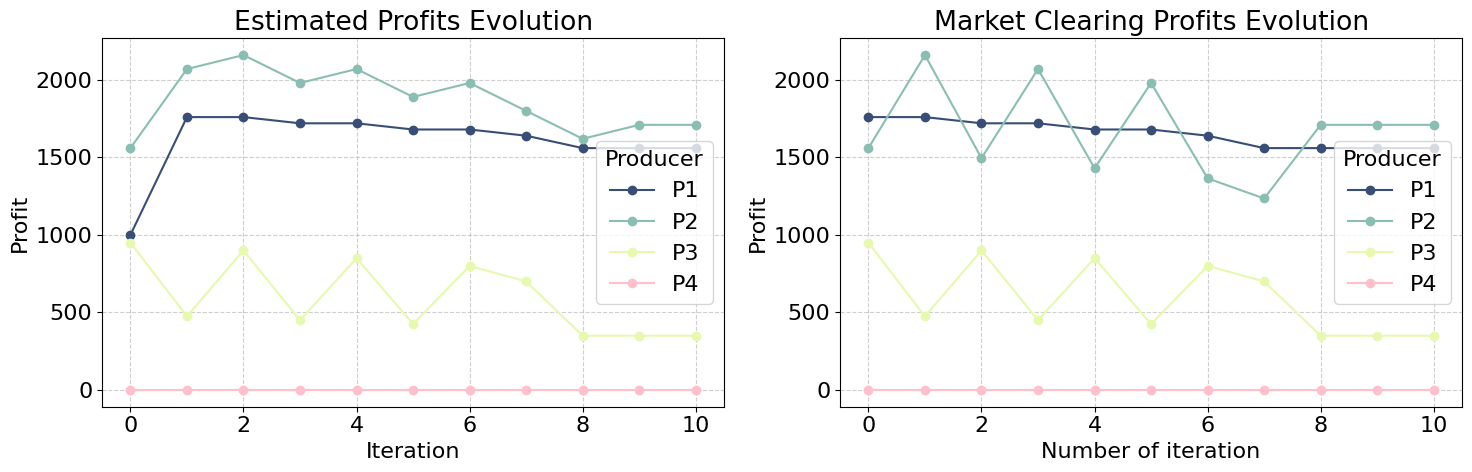

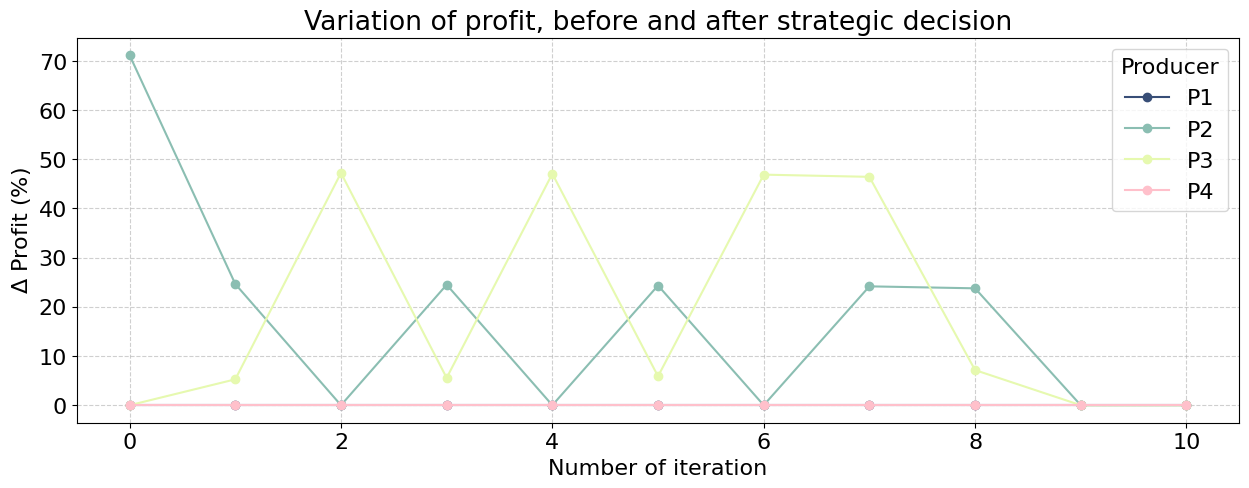

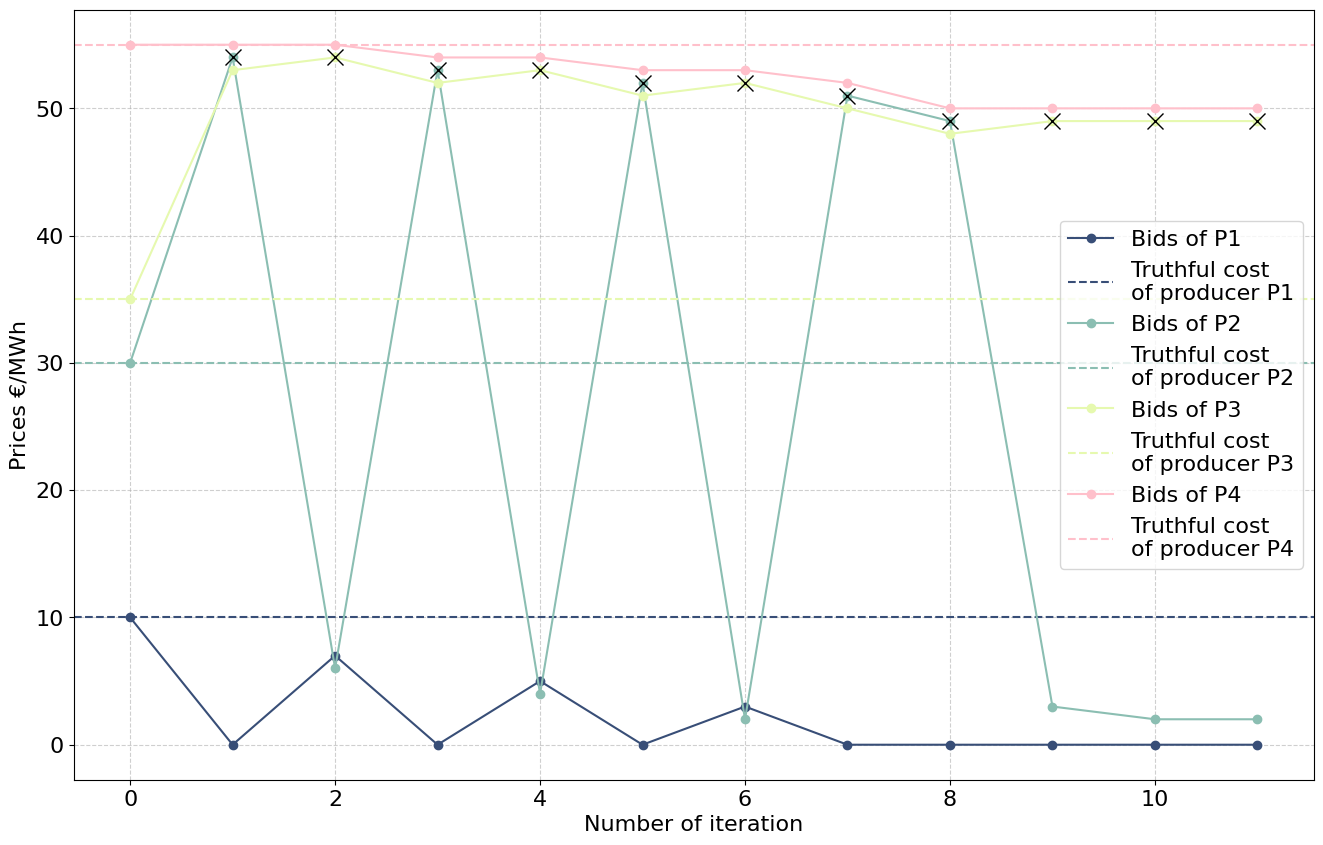

   0     1     2     3     4     5     6     7     8     9     10    11
0  10   0.0   7.0   0.0   5.0   0.0   3.0   0.0   0.0   0.0   0.0   0.0
1  30  54.0   6.0  53.0   4.0  52.0   2.0  51.0  49.0   3.0   2.0   2.0
2  35  53.0  54.0  52.0  53.0  51.0  52.0  50.0  48.0  49.0  49.0  49.0
3  55  55.0  55.0  54.0  54.0  53.0  53.0  52.0  50.0  50.0  50.0  50.0


In [11]:
br.plot_estimated_profits_evo()
br.plot_strategic_behaviour()
print(utils.plot_bids_evolution(prod_df, br.dict_alphas, single_graph=True, market_prices=br.prices))

In [12]:
mc = MarketClearing(bids=marginal_costs, marginal_costs=marginal_costs, demand=demand, prod_df=prod_df)

Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
QCPDual  1

Academic license 2635697 - for non-commercial use only - registered to s2___@dtu.dk
Optimize a model with 9 rows, 4 columns and 12 nonzeros
Model fingerprint: 0x5845b6b1
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 2e+02]
Presolve removed 8 rows and 1 columns
Presolve time: 0.01s
Presolved: 1 rows, 3 columns, 3 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.8500000e+03   3.125000e+00   0.000000e+00      0s
       1    3.9750000e+03   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and

RangeIndex(start=0, stop=4, step=1)
0
RangeIndex(start=0, stop=4, step=1)
1
1
RangeIndex(start=0, stop=4, step=1)
2
2
RangeIndex(start=0, stop=4, step=1)
3
3
   production  bids producer  capacities    color   xpos  cumulative_capa
0        40.0    10       P1          40  #384E77   20.0               40
1        90.0    30       P2          90  #8BBEB2   85.0              130
2        25.0    35       P3          50  #E6F9AF  155.0              180
3         0.0    55       P4          60     pink  210.0              240
Power plant that sets the electricity price is:  2
RangeIndex(start=0, stop=4, step=1)
0
RangeIndex(start=0, stop=4, step=1)
1
1
RangeIndex(start=0, stop=4, step=1)
2
2
RangeIndex(start=0, stop=4, step=1)
3
3
   production  bids producer  capacities    color   xpos  cumulative_capa
0        40.0   0.0       P1          40  #384E77   20.0               40
1        90.0   2.0       P2          90  #8BBEB2   85.0              130
2        25.0  49.0       P3          50 

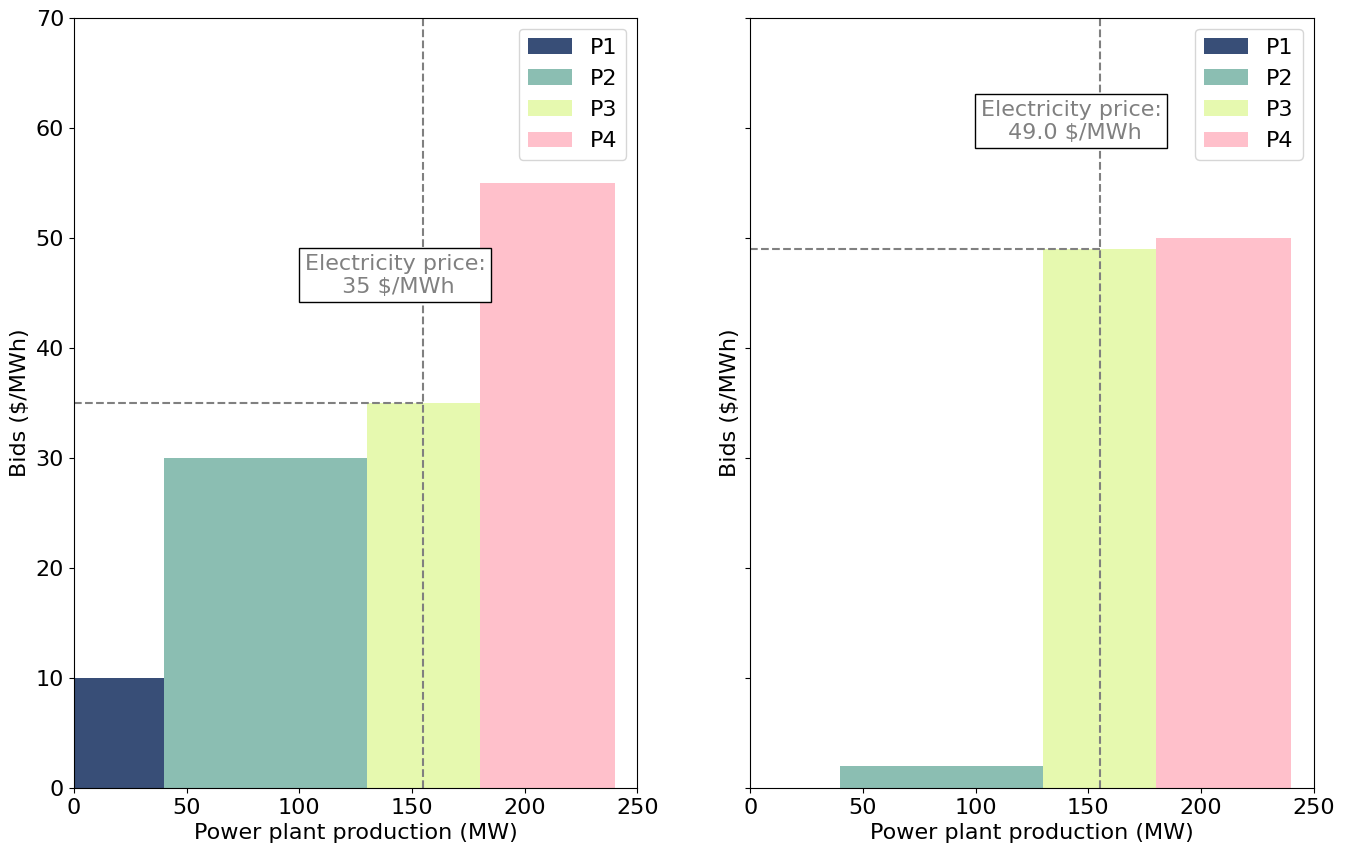

In [13]:
results_br, as_converged = br.get_results()
results_mc = mc.get_results()
utils.plot_dispatch_br_mc(results_mc=results_mc, results_br=results_br, demand=demand)

In [ ]:
from varying_fuel_costs import search_worst_inefficiency, inefficiencies
import matplotlib.pyplot as plt

max_poa = search_worst_inefficiency(prod_df= prod_df, demand=demand, nb_segments=3)


vals = inefficiencies(5, 100, 10, 50, nb_segments=3)
players = list(range(3, 3 + len(vals)))   # MATCH LENGTH



plt.figure(figsize=(7,5))
plt.plot(players, vals, marker='o')
plt.title("Market Inefficiency vs Number of Producers")
plt.xlabel("Number of Producers")
plt.ylabel("Inefficiency")
plt.grid(True)
plt.xticks(players)
plt.show()

all_vals = {}
for seg in [1,2,3,4]:
    vals = inefficiencies(4, 100, 10, 50, nb_segments=seg)
    all_vals[seg] = vals

plt.figure(figsize=(8,6))
for seg, vals in all_vals.items():
    players = list(range(3, 3 + len(vals)))
    plt.plot(players, vals, marker='o', label=f"{seg} segments")

plt.title("Inefficiency vs Number of Producers for Different Bid Segments")
plt.xlabel("Number of Producers")
plt.ylabel("Inefficiency")
plt.grid(True)
plt.legend()
plt.show()
